In [2]:
import pickle
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker


from IPython.display import display, clear_output

from stats_utils import kde_scatter_estimate,KDEScatterData, plot_scatter_from_kde

In [ ]:
mpl.rcdefaults()
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=22)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=22)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels
plt.rc('legend', fontsize=22)    # legend fontsize
plt.rc('figure', titlesize=14)   # fontsize of the figure title


In [4]:
BATCH = "008"

In [5]:
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"
NODES = Path("~/tesi/sarafu/final_simulations").expanduser() / BATCH

FIGURES = Path("~/papers/adtxns_paper/figures/kde").expanduser()


In [6]:
with open(SARAFU_PICKLED / "sarafu.pkl", "rb") as f:
    sarafu = pickle.load(f)

In [7]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))
# metadata

In [8]:
burstiness = 0.75
spending_noise = 1
QUERY = f"s == {spending_noise} and burstiness == {burstiness}"

In [9]:
sf = mticker.ScalarFormatter(useMathText=True)
sf.set_powerlimits((0, 0))      # force a single ×10^n
sf.set_scientific(True)

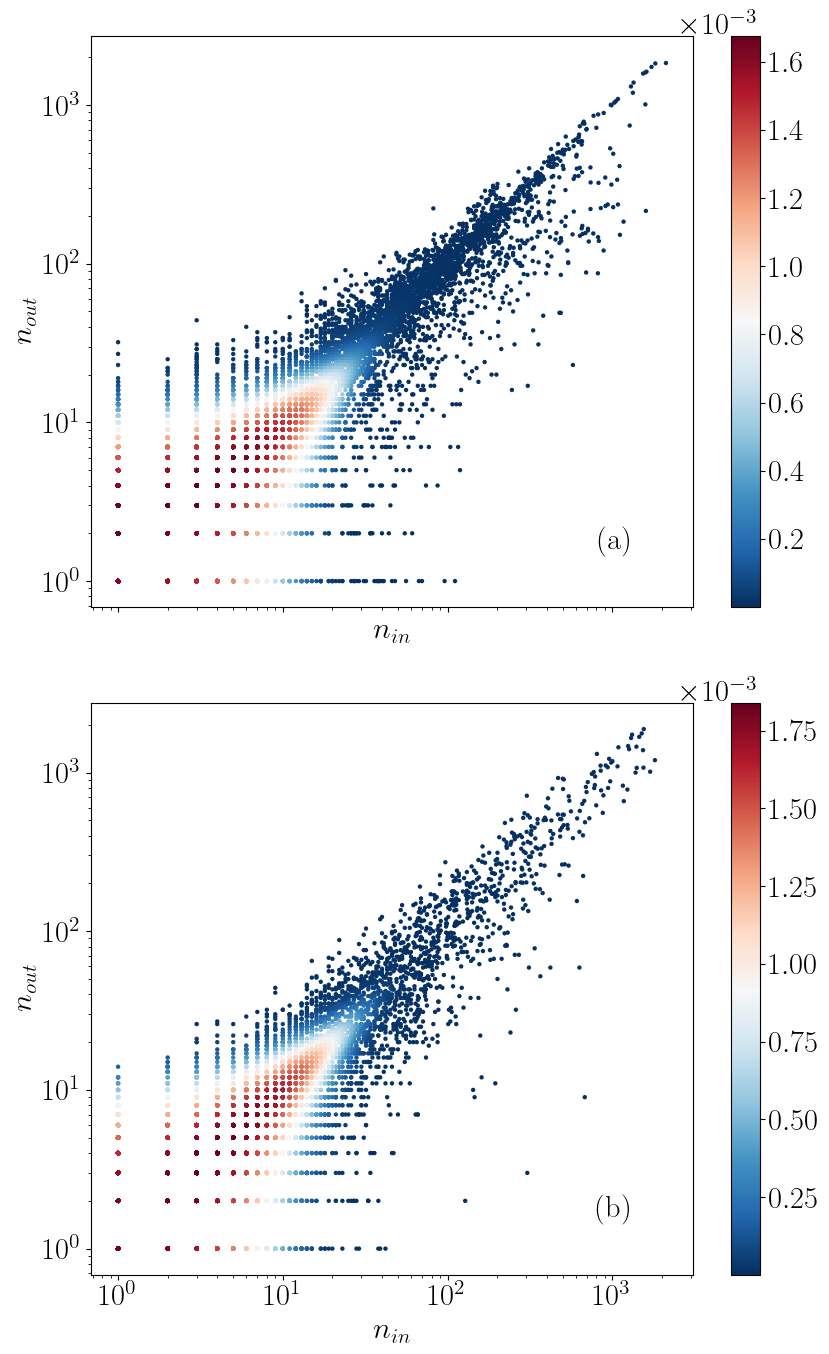

In [ ]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "tx_in-tx_out"
shared = False
disp = "cols"
tag = f"s={spending_noise}__b={burstiness}"
xlabel = "$n_{in}$"
ylabel = "$n_{out}$"
cmap = "RdBu_r"




simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__{tag}.pkl", "rb"))



# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                                },
    cmap=cmap

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, cb2 = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,                 
                 },
    cmap= cmap
    
)

cb2.set_label(None)

ax2.text(
    0.9,
    0.1,
    f"(b) ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# shared = 0
if shared:
    cbar = fig.colorbar(sc1, ax=axs, shrink=0.6)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)




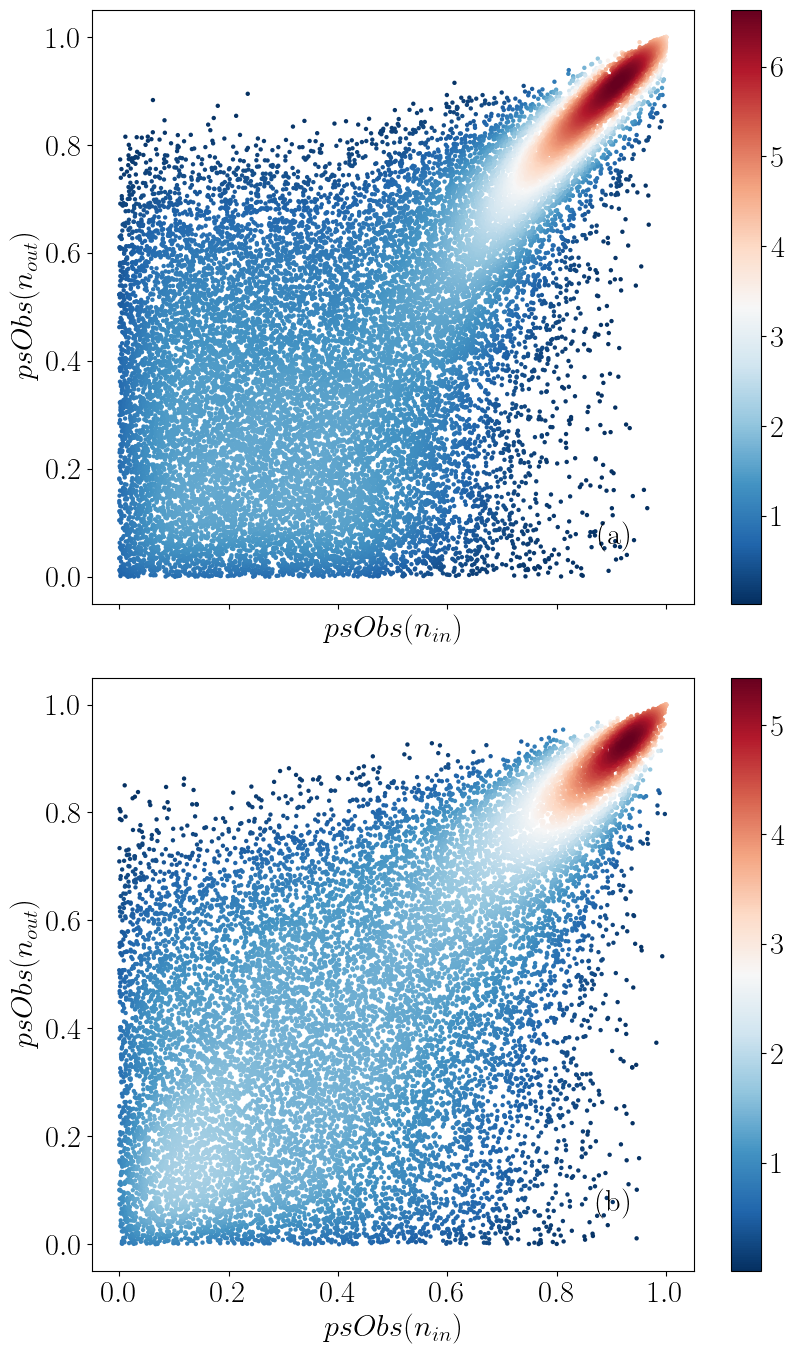

In [ ]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "copula-tx_in-tx_out"
shared = False
disp = "cols"
tag = f"s={spending_noise}__b={burstiness}"
xlabel = "$psObs(n_{in})$"
ylabel = "$psObs(n_{out})$"
cmap = "RdBu_r"
loglog = False



simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__{tag}.pkl", "rb"))



# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,                 
                 },
                 cmap=cmap,

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, cb2 = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                 }, 
    cmap=cmap
       
)

cb2.set_label(None)

ax2.text(
    0.9,
    0.1,
    f"(b) ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# shared = 0
if shared:
    cbar = fig.colorbar(sc1, ax=axs, shrink=0.6)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)




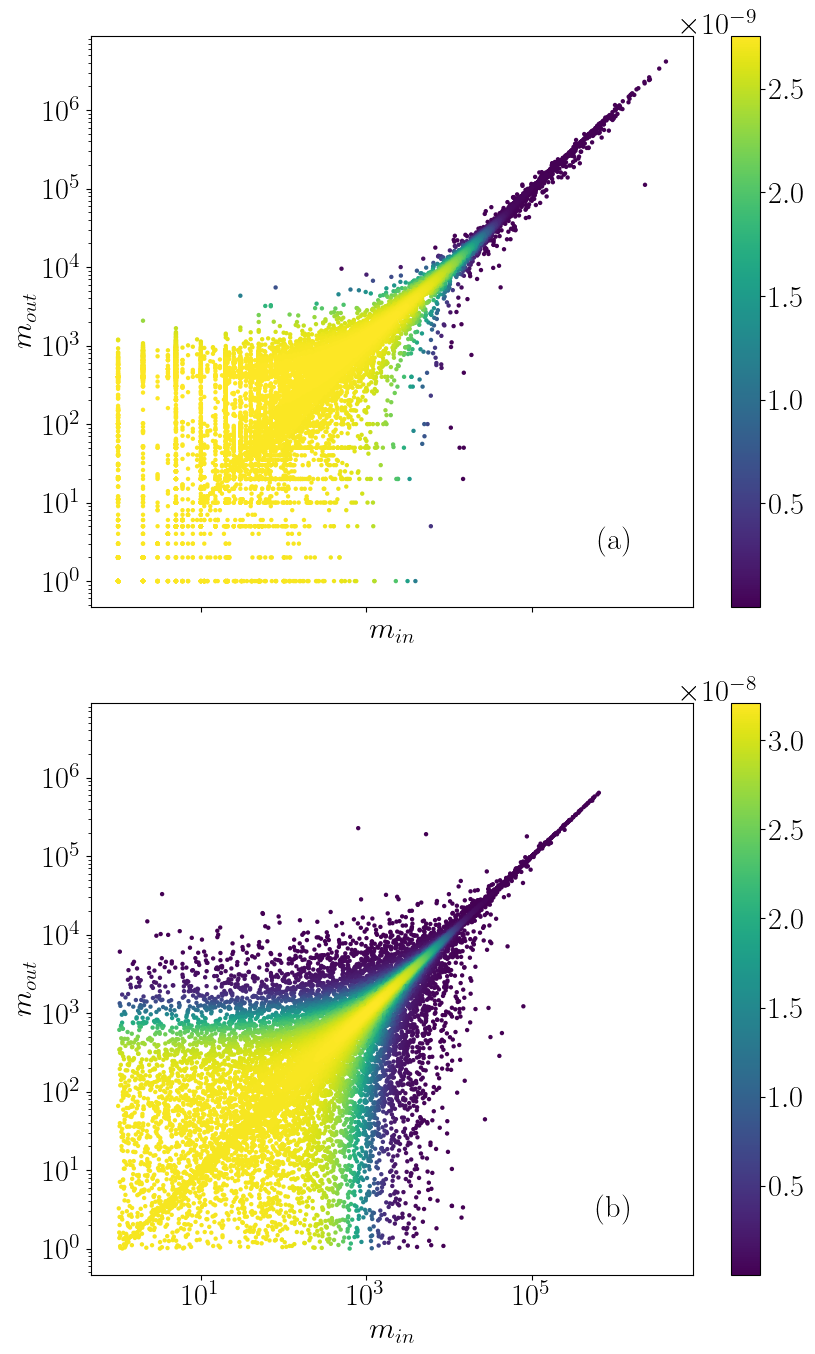

In [ ]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "vol_in-vol_out"
shared = False
disp = "cols"
tag = f"s={spending_noise}__b={burstiness}"
xlabel = "$m_{in}$"
ylabel = "$m_{out}$"
cmap = 'viridis'
loglog = True



simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__{tag}.pkl", "rb"))



# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                 "cmap": cmap
                 },
    cmap=cmap
    

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, cb2 = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    cmap=cmap,

    colorbar_kw={"format": sf,
                 "cmap": cmap
                 }
    
)

cb2.set_label(None)

ax2.text(
    0.9,
    0.1,
    f"(b) ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# shared = 0
if shared:
    cbar = fig.colorbar(sc1, ax=axs, shrink=0.6)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)




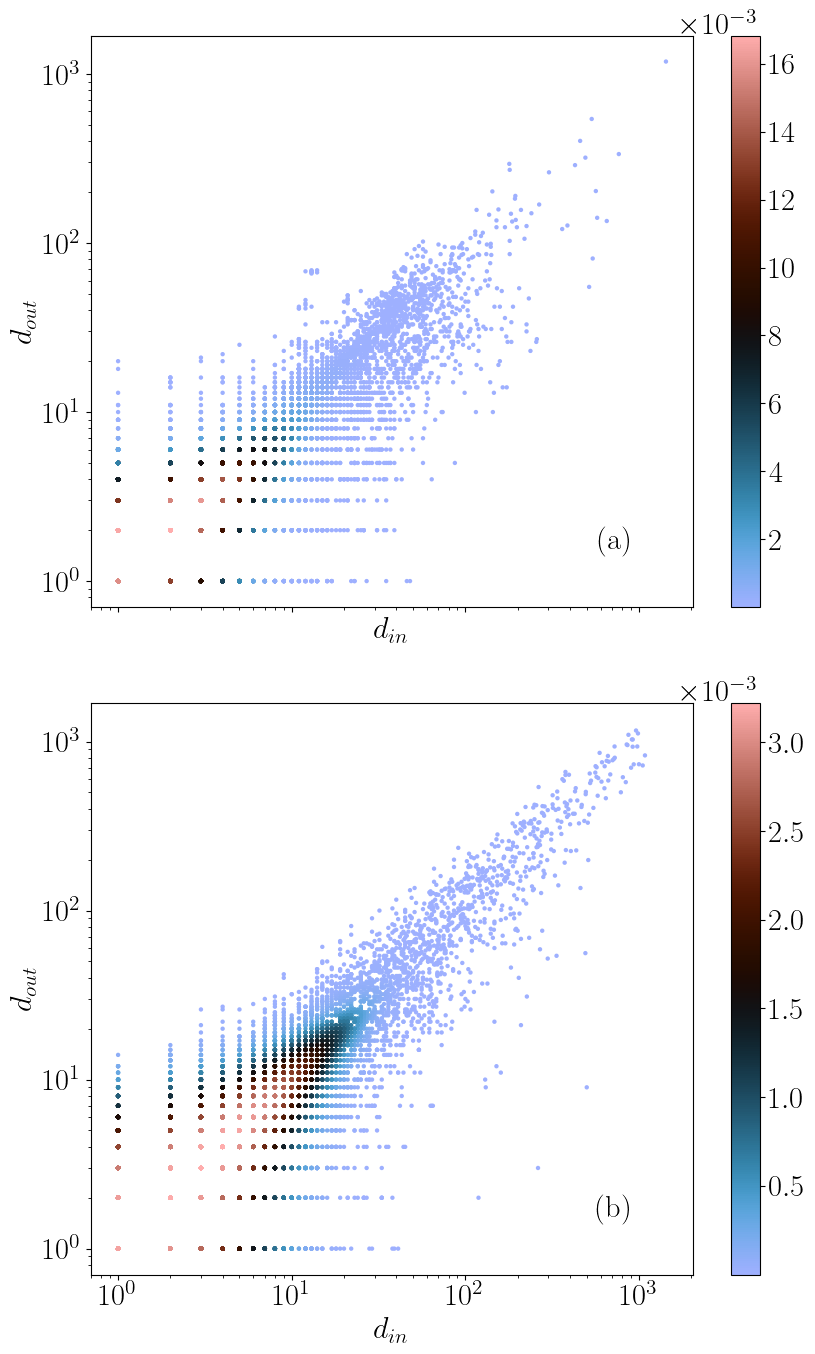

In [ ]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "in_deg-out_deg"
shared = False
disp = "cols"
tag = f"s={spending_noise}__b={burstiness}"
xlabel = "$d_{in}$"
ylabel = "$d_{out}$"
cmap = 'berlin'
loglog = True



simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__{tag}.pkl", "rb"))



# shared normalization (critical)
if shared:
    z_all = np.hstack([k1.z, k2.z])
    norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                 "cmap": cmap
                 },
    cmap=cmap
    

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, cb2 = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    cmap=cmap,

    colorbar_kw={"format": sf,
                 "cmap": cmap
                 }
    
)

cb2.set_label(None)

ax2.text(
    0.9,
    0.1,
    f"(b) ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# shared = 0
if shared:
    cbar = fig.colorbar(sc1, ax=axs, shrink=0.6)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)




In [14]:

# --- config ---
tag = f"s={spending_noise}__b={burstiness}"
simu_id = metadata.query(QUERY).iloc[0].simulation_id
disp = "2x2"
shared = False

# column 1 (tx)
keyword_tx = "tx_in-tx_out"
xlabel_tx = "$n_{in}$"
ylabel_tx = "$n_{out}$"
cmap_tx = "RdBu_r"
loglog_tx = True  # keep as in your first script

# column 2 (vol)
keyword_vol = "vol_in-vol_out"
xlabel_vol = "$m_{in}$"
ylabel_vol = "$m_{out}$"
cmap_vol = "viridis"
loglog_vol = True

# --- load KDEs ---
k_tx_1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword_tx}__s=NA__b=NA.pkl", "rb"))
k_tx_2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword_tx}__{tag}.pkl", "rb"))

k_vol_1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword_vol}__s=NA__b=NA.pkl", "rb"))
k_vol_2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword_vol}__{tag}.pkl", "rb"))


In [15]:
mpl.rcdefaults()

#* BIGGER SIZE
K = 1.5
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] ='STIXGeneral'
plt.rc('font', size=int(K*22))          # controls default text sizes
plt.rc('axes', titlesize=int(K*14))     # fontsize of the axes title
plt.rc('axes', labelsize=int(K*22))     # fontsize of the x and y labels
plt.rc('xtick', labelsize=int(K*22))    # fontsize of the tick labels
plt.rc('ytick', labelsize=int(K*22))    # fontsize of the tick labels
plt.rc('legend', fontsize=int(K*22))    # legend fontsize
plt.rc('figure', titlesize=int(K*14))   # fontsize of the figure title


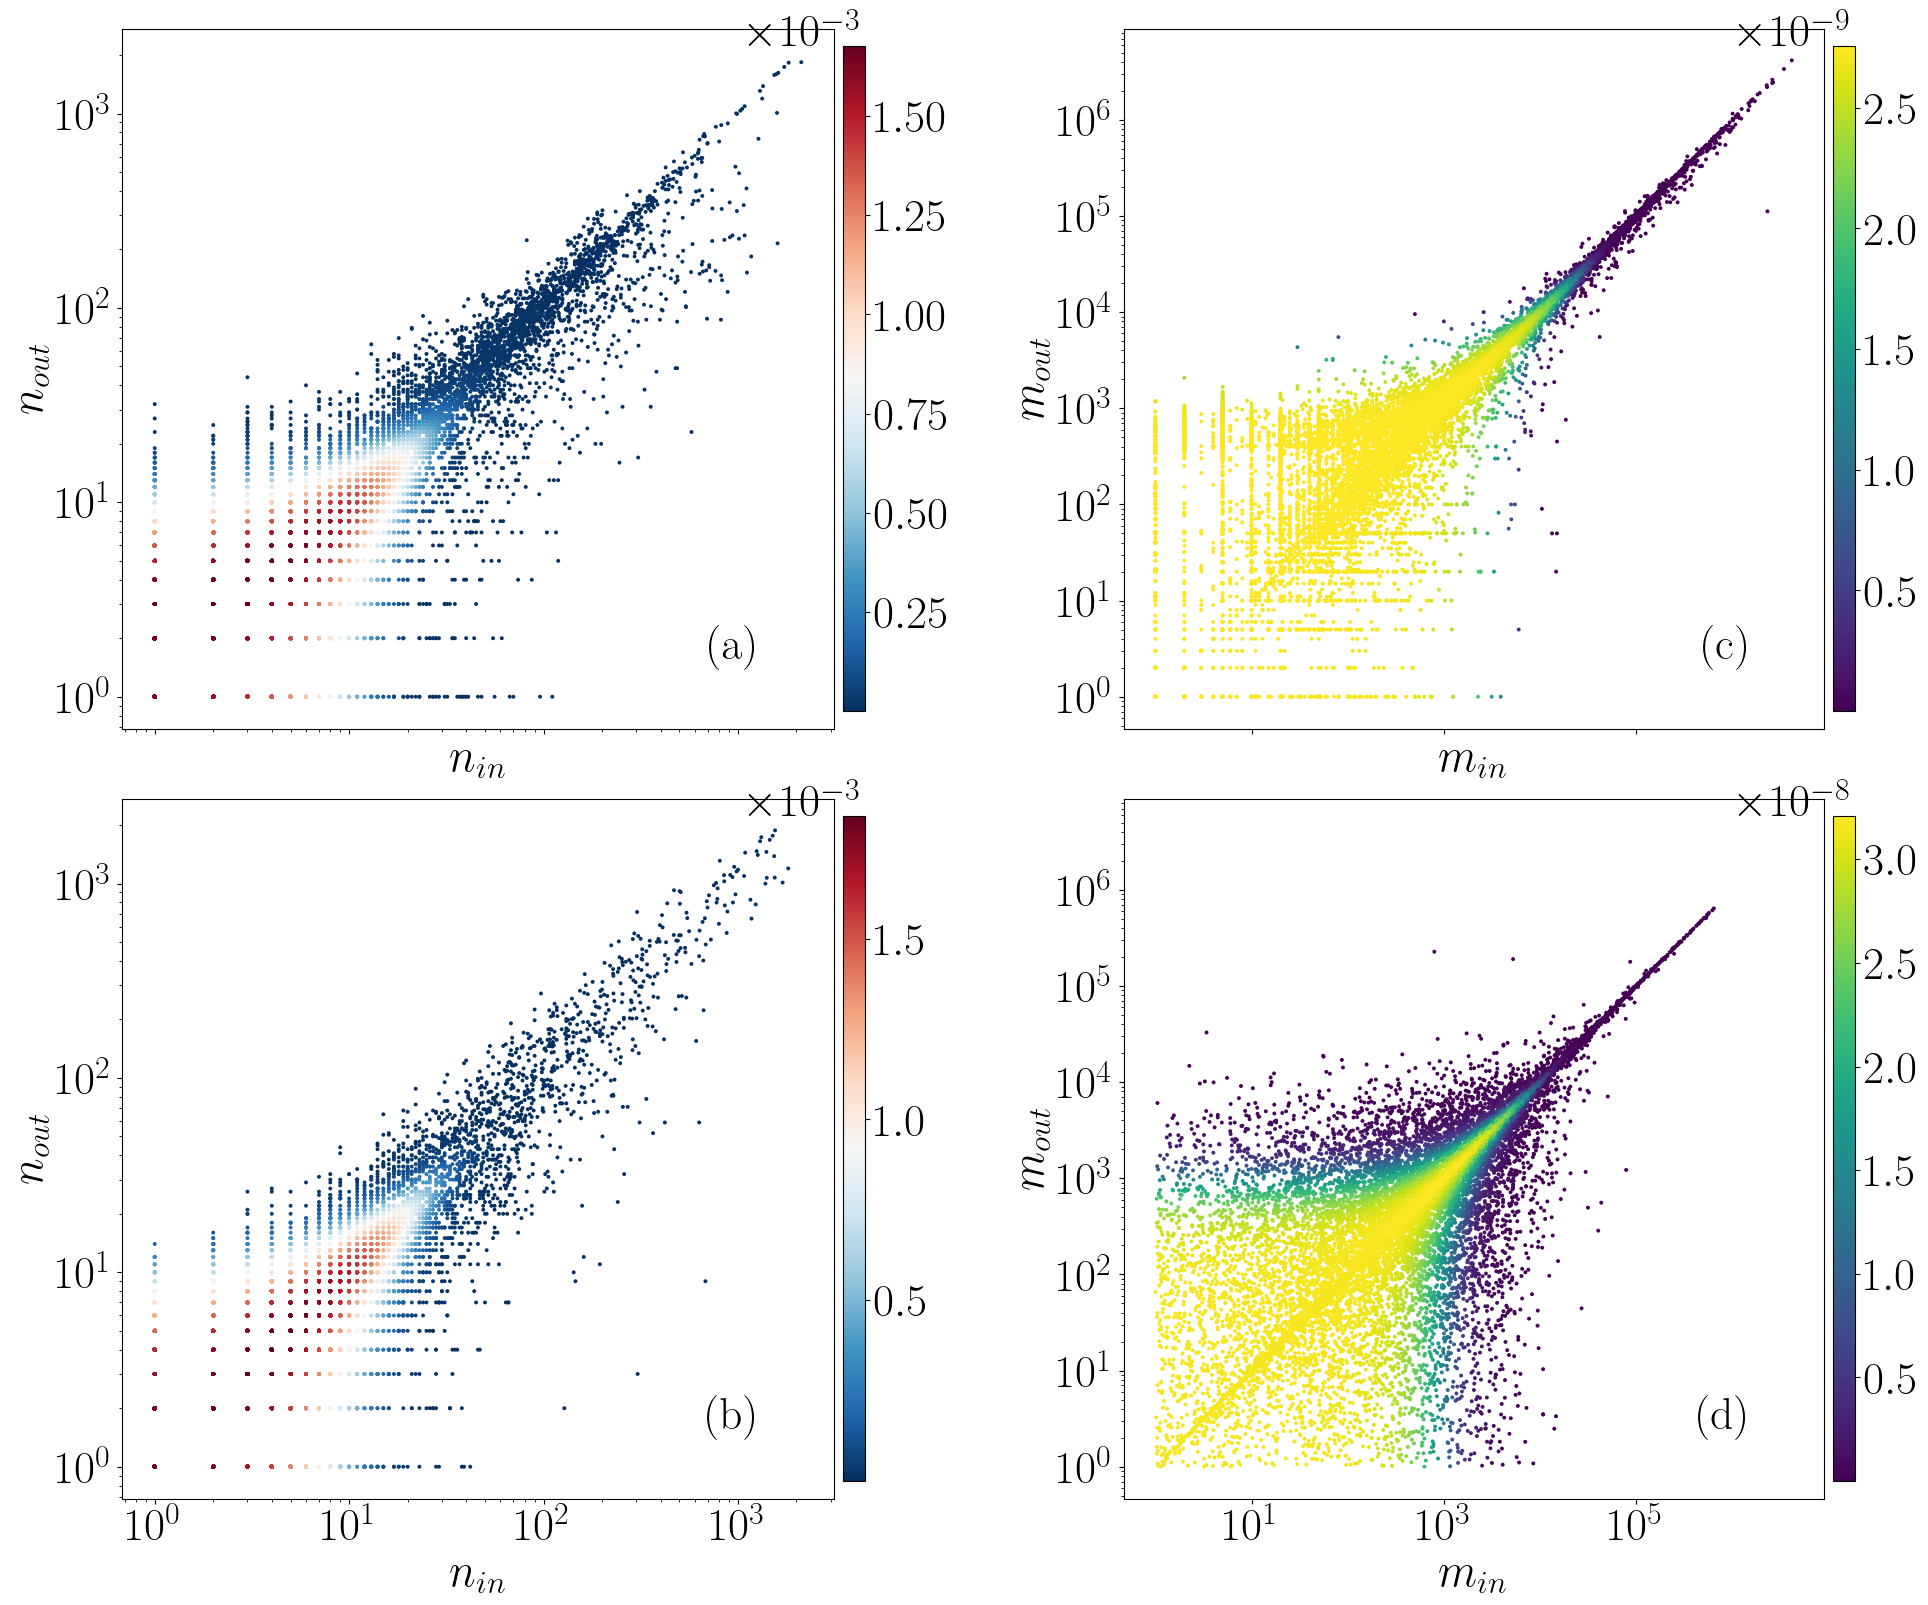

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# -----------------------------
# USER CONTROLS (edit here)
# -----------------------------
R, C = 2, 2
ax_w, ax_h = 9, 7
# dpi = 100

# margins and spacing (fractions of the figure)
left, right = 0.02, 0.98
bottom, top = 0.02, 0.98
wspace, hspace = 0.10, 0.10

# shared colorbar per column? (tx column and vol column)
# - True  => one colorbar for left column + one for right column
# - False => one colorbar per axes
shared = False

# per-axes colorbar settings (used when shared == False)
# you can override per plot (see below)
cb_default = dict(pad=0.01, fraction=0.046, shrink=0.95, aspect=30)

# shared colorbar settings (used when shared == True)
cb_shared_tx = dict(pad=0.02, shrink=0.85)
cb_shared_vol = dict(pad=0.02, shrink=0.85)

# scatter defaults
scatter_default = dict(s=8, linewidths=0, edgecolors="none")

# formatters (scientific notation)
sf_tx = mticker.ScalarFormatter(useMathText=True)
sf_tx.set_powerlimits((0, 0))  # always scientific

sf_vol = mticker.ScalarFormatter(useMathText=True)
sf_vol.set_powerlimits((0, 0))  # always scientific

# -----------------------------
# FIGURE LAYOUT (axes size fixed)
# -----------------------------
fig_w = ax_w * (C + (C - 1) * wspace) / (right - left)
fig_h = ax_h * (R + (R - 1) * hspace) / (top - bottom)

fig, axs = plt.subplots(
    R, C,
    figsize=(fig_w, fig_h),
    dpi=dpi,
    sharex="col",
    sharey="col",
)
fig.subplots_adjust(
    left=left, right=right,
    bottom=bottom, top=top,
    wspace=wspace, hspace=hspace
)

# -----------------------------
# PLOT (1) tx: sarafu (top-left)
# -----------------------------
ax = axs[0, 0]

# Expect k_tx_1 to expose x,y,z (or adapt the next 3 lines)
x = np.asarray(k_tx_1.x)
y = np.asarray(k_tx_1.y)
z = np.asarray(k_tx_1.z)

sc_tx1 = ax.scatter(
    x, y,
    c=z,
    cmap=cmap_tx,
    # norm=(norm_tx if shared else None),
    **scatter_default
)

# log scaling (expects loglog_tx like (True/False, True/False) OR a single bool)
if isinstance(loglog_tx, (tuple, list)) and len(loglog_tx) == 2:
    if loglog_tx[0]: ax.set_xscale("log")
    if loglog_tx[1]: ax.set_yscale("log")
else:
    if loglog_tx:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_tx)
ax.set_ylabel(ylabel_tx)
ax.text(0.9, 0.1, "(a)", transform=ax.transAxes, ha="right")

cb1 = None
if not shared:
    cb1 = fig.colorbar(sc_tx1, ax=ax, format=sf_tx, **cb_default)
    cb1.set_label(None)

# -----------------------------
# PLOT (2) tx: simu (bottom-left)
# -----------------------------
ax = axs[1, 0]

x = np.asarray(k_tx_2.x)
y = np.asarray(k_tx_2.y)
z = np.asarray(k_tx_2.z)

sc_tx2 = ax.scatter(
    x, y,
    c=z,
    cmap=cmap_tx,
    # norm=(norm_tx if shared else None),
    **scatter_default
)

if isinstance(loglog_tx, (tuple, list)) and len(loglog_tx) == 2:
    if loglog_tx[0]: ax.set_xscale("log")
    if loglog_tx[1]: ax.set_yscale("log")
else:
    if loglog_tx:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_tx)
ax.set_ylabel(ylabel_tx)
ax.text(0.9, 0.1, "(b)", transform=ax.transAxes, ha="right")

cb2 = None
if not shared:
    # you can override per-plot settings here if you want:
    # cb_kw = dict(cb_default); cb_kw.update(dict(pad=0.03, shrink=0.9))
    cb2 = fig.colorbar(sc_tx2, ax=ax, format=sf_tx, **cb_default)
    cb2.set_label(None)

# -----------------------------
# PLOT (3) vol: sarafu (top-right)
# -----------------------------
ax = axs[0, 1]

x = np.asarray(k_vol_1.x)
y = np.asarray(k_vol_1.y)
z = np.asarray(k_vol_1.z)

sc_vol1 = ax.scatter(
    x, y,
    c=z,
    cmap=cmap_vol,
    # norm=(norm_vol if shared else None),
    **scatter_default
)

if isinstance(loglog_vol, (tuple, list)) and len(loglog_vol) == 2:
    if loglog_vol[0]: ax.set_xscale("log")
    if loglog_vol[1]: ax.set_yscale("log")
else:
    if loglog_vol:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_vol)
ax.set_ylabel(ylabel_vol)
ax.text(0.9, 0.1, "(c)", transform=ax.transAxes, ha="right")

cb3 = None
if not shared:
    cb3 = fig.colorbar(sc_vol1, ax=ax, format=sf_vol, **cb_default)
    cb3.set_label(None)

# -----------------------------
# PLOT (4) vol: simu (bottom-right)
# -----------------------------
ax = axs[1, 1]

x = np.asarray(k_vol_2.x)
y = np.asarray(k_vol_2.y)
z = np.asarray(k_vol_2.z)

sc_vol2 = ax.scatter(
    x, y,
    c=z,
    cmap=cmap_vol,
    # norm=(norm_vol if shared else None),
    **scatter_default
)

if isinstance(loglog_vol, (tuple, list)) and len(loglog_vol) == 2:
    if loglog_vol[0]: ax.set_xscale("log")
    if loglog_vol[1]: ax.set_yscale("log")
else:
    if loglog_vol:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_vol)
ax.set_ylabel(ylabel_vol)
ax.text(0.9, 0.1, "(d)", transform=ax.transAxes, ha="right")

cb4 = None
if not shared:
    cb4 = fig.colorbar(sc_vol2, ax=ax, format=sf_vol, **cb_default)
    cb4.set_label(None)

# -----------------------------
# SHARED COLORBARS (one per column)
# -----------------------------
if shared:
    # left column uses tx formatter
    cbar_tx = fig.colorbar(sc_tx1, ax=axs[:, 0], format=sf_tx, **cb_shared_tx)
    cbar_tx.set_label(None)

    # right column uses vol formatter
    cbar_vol = fig.colorbar(sc_vol1, ax=axs[:, 1], format=sf_vol, **cb_shared_vol)
    cbar_vol.set_label(None)

# -----------------------------
# FINAL TOUCHES
# -----------------------------
for ax in axs.flatten():
    ax.set_aspect("equal")


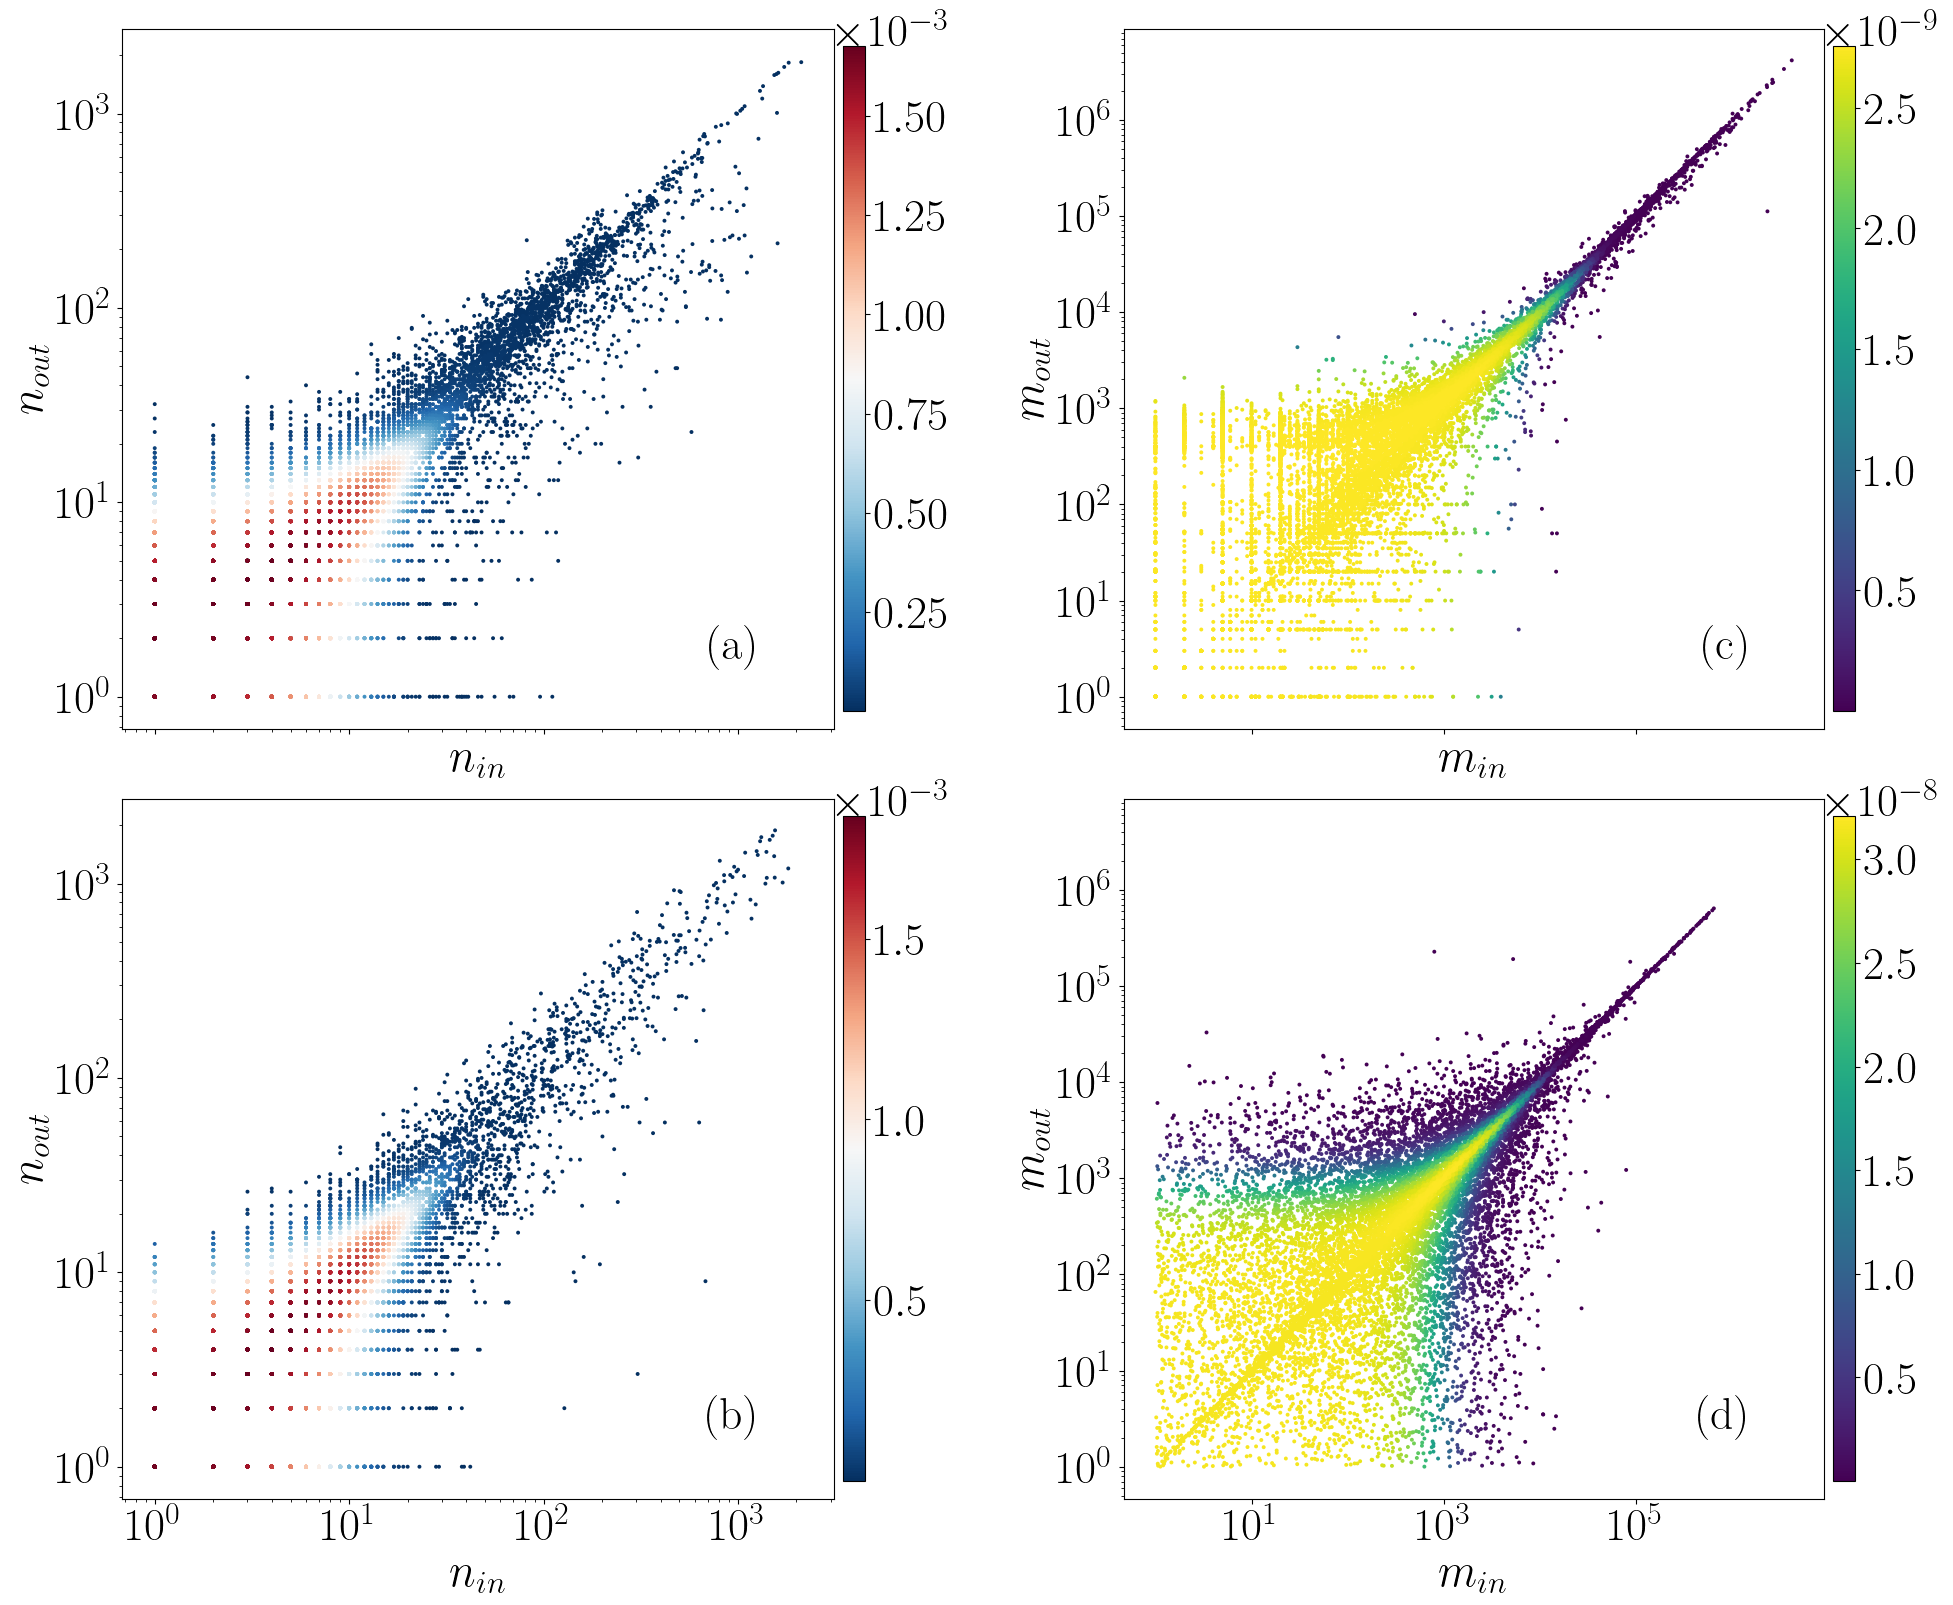

In [52]:
cbs = [cb1, cb2, cb3, cb4]

for cb in cbs:
    cax = cb.ax
    cax.yaxis.get_offset_text().set_x(5)
    cax.yaxis.get_offset_text().set_y(5)

    # # current position in figure coordinates
    # x0, y0, w, h = cax.get_position().bounds

    # # example: move colorbar closer to the plot
    # cax.set_position([x0 - 0.03, y0, w, h])

fig.canvas.draw()  # force a draw (not idle)

clear_output(wait=True)
display(fig)



In [48]:

# plt.tight_layout()
plt.show()

fig.savefig(FIGURES / f"{disp}__metrics=({keyword_tx})+({keyword_vol})__{tag}.pdf")


In [ ]:

if shared:
    # --- shared norms within each column ---
    z_tx = np.hstack([k_tx_1.z, k_tx_2.z])
    norm_tx = mcolors.Normalize(vmin=z_tx.min(), vmax=z_tx.max())

    z_vol = np.hstack([k_vol_1.z, k_vol_2.z])
    norm_vol = mcolors.Normalize(vmin=z_vol.min(), vmax=z_vol.max())


sf_tx  = mticker.ScalarFormatter(useMathText=True)
sf_tx.set_powerlimits((0, 0))     # always scientific

# R,C = 2,2
# W = 9
# H = 7
# DPI = 500


# # --- figure layout: [[1,3],[2,4]] ---
# fig, axs = plt.subplots(
#     R,C,
#     figsize=(9*C,7*R),
#     dpi = DPI,
#     sharex="col",
#     sharey="col",
# )

# import matplotlib.pyplot as plt

R, C = 2, 2
ax_w, ax_h = 9, 7
dpi = 500

# choose margins and spacing (fractions of the figure)
left, right = 0.12, 0.98
bottom, top = 0.12, 0.95
wspace, hspace = 0.30, 0.30

# compute required figure size so EACH axes box is ax_w x ax_h inches
fig_w = ax_w * (C + (C - 1) * wspace) / (right - left)
fig_h = ax_h * (R + (R - 1) * hspace) / (top - bottom)

fig, axs = plt.subplots(R, C, figsize=(fig_w, fig_h), dpi=dpi, sharex="col", sharey="col")
fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace, hspace=hspace)


# ---- (1) tx: sarafu (top-left) ----
ax, sc_tx1, cb = plot_scatter_from_kde(
    k_tx_1,
    ax=axs[0, 0],
    norm=norm_tx if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_tx,
    x_label=xlabel_tx,
    y_label=ylabel_tx,
    colorbar_kw={"format": sf_tx},
    cmap=cmap_tx,
)
cb.set_label(None)
axs[0, 0].text(0.9, 0.1, "(a) sarafu", transform=axs[0, 0].transAxes, ha="right")

# ---- (2) tx: simu (bottom-left) ----
ax, sc_tx2, cb = plot_scatter_from_kde(
    k_tx_2,
    ax=axs[1, 0],
    norm=norm_tx if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_tx,
    x_label=xlabel_tx,
    y_label=ylabel_tx,
    colorbar_kw={"format": sf_tx},
    cmap=cmap_tx,
)
cb.set_label(None)

sf_vol = mticker.ScalarFormatter(useMathText=True)
sf_vol.set_powerlimits((0, 0))    # (optional) keep consistent

axs[1, 0].text(0.9, 0.1, "(b) simu", transform=axs[1, 0].transAxes, ha="right")

# ---- (3) vol: sarafu (top-right) ----
ax, sc_vol1, cb = plot_scatter_from_kde(
    k_vol_1,
    ax=axs[0, 1],
    norm=norm_vol if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_vol,
    x_label=xlabel_vol,
    y_label=ylabel_vol,
    colorbar_kw={"format": sf_vol},
    cmap=cmap_vol,
)
cb.set_label(None)

axs[0, 1].text(0.9, 0.1, "(c) sarafu", transform=axs[0, 1].transAxes, ha="right")

# ---- (4) vol: simu (bottom-right) ----
ax, sc_vol2, cb = plot_scatter_from_kde(
    k_vol_2,
    ax=axs[1, 1],
    norm=norm_vol if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_vol,
    x_label=xlabel_vol,
    y_label=ylabel_vol,
    colorbar_kw={"format": sf_vol},
    cmap=cmap_vol,
)
cb.set_label(None)

axs[1, 1].text(0.9, 0.1, "(d) simu", transform=axs[1, 1].transAxes, ha="right")

if shared:
    # --- one shared colorbar per column ---
    cbar_tx = fig.colorbar(sc_tx1, ax=axs[:, 0], shrink=0.85, pad=0.02)
    cbar_tx.set_label(None)

    cbar_vol = fig.colorbar(sc_vol1, ax=axs[:, 1], shrink=0.85, pad=0.02)
    cbar_vol.set_label(None)

# fig.subplots_adjust(wspace=0.1, hspace=0.1)
for ax in axs.flatten():
    ax.set_aspect('equal')

# plt.tight_layout()
plt.show()

# fig.savefig(FIGURES / f"{disp}__metrics=({keyword_tx})+({keyword_vol})__{tag}.pdf")


In [ ]:
W = 9
H = 7
R, C = rows,cols


fig, axs = plt.subplots(R, C, 
                        figsize=(C*W, R*H),
                          sharex="col", 
                          sharey="col")


In [73]:
from typing import Optional
import numpy as np

def plot_scatter_from_kde(
    kde_data: KDEScatterData,
    ax,
    *,
    x_label: Optional[str] = "X",
    y_label: Optional[str] = "Y",
    log_scale: bool = False,
    sort_by_density: bool = True,
    cmap: str = "plasma",
    norm=None,
    rasterized: bool = True,
    scatter_kw: Optional[dict] = None,
):
    """
    Plot precomputed KDE scatter. Does NOT create a colorbar.
    Returns: ax, PathCollection
    """
    if ax is None:
        raise ValueError("ax must be provided (create the figure/axes outside).")

    if scatter_kw is None:
        scatter_kw = {}

    x = np.asarray(kde_data.x)
    y = np.asarray(kde_data.y)
    z = np.asarray(kde_data.z)

    if sort_by_density:
        order = np.argsort(z)  # low first, dense last
        x, y, z = x[order], y[order], z[order]

    skw = dict(s=10, linewidths=0, alpha=1.0)
    skw.update(scatter_kw)

    sc = ax.scatter(
        x, y,
        c=z,
        cmap=cmap,
        norm=norm,
        rasterized=rasterized,
        **skw,
    )

    if x_label is not None:
        ax.set_xlabel(x_label)
    if y_label is not None:
        ax.set_ylabel(y_label)

    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")

    return ax, sc


/tmp/ipykernel_7593/2619815482.py:118: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 10000)
/tmp/ipykernel_7593/2619815482.py:119: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 10000)


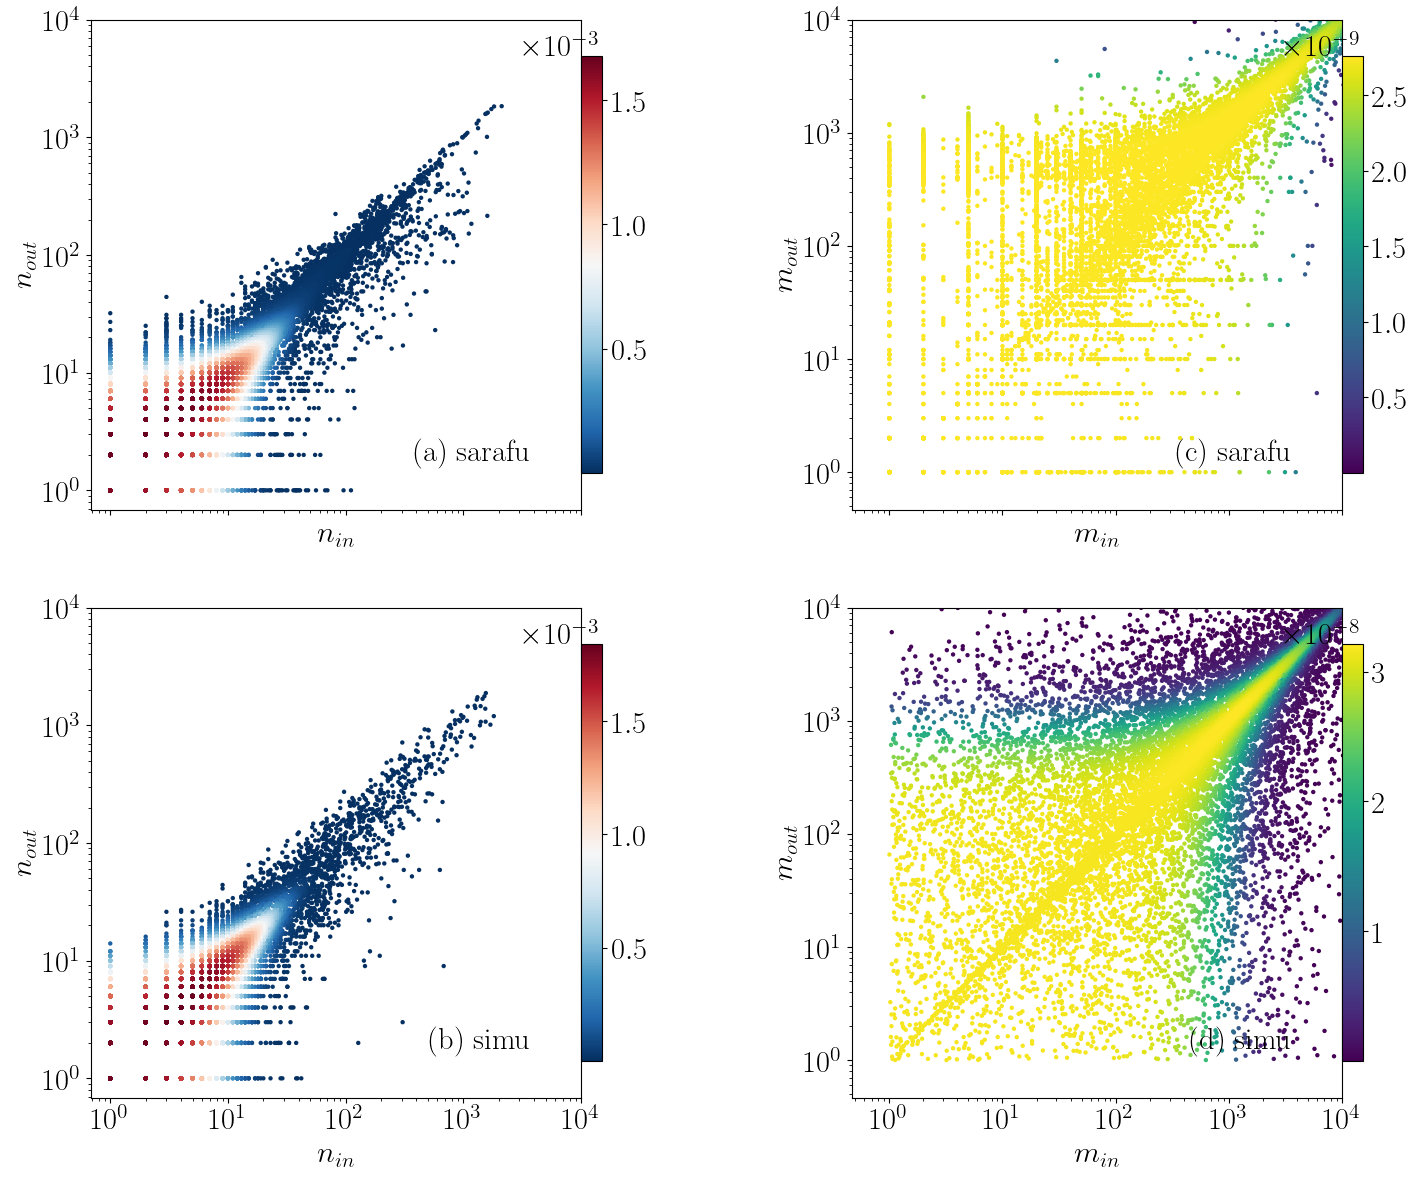

In [80]:
# --- config ---
tag = f"s={spending_noise}__b={burstiness}"
simu_id = metadata.query(QUERY).iloc[0].simulation_id
disp = "2x2"
shared = False

# column 1 (tx)
keyword_tx = "tx_in-tx_out"
xlabel_tx = "$n_{in}$"
ylabel_tx = "$n_{out}$"
cmap_tx = "RdBu_r"
loglog_tx = True

# column 2 (vol)
keyword_vol = "vol_in-vol_out"
xlabel_vol = "$m_{in}$"
ylabel_vol = "$m_{out}$"
cmap_vol = "viridis"
loglog_vol = True

# --- load KDEs ---
k_tx_1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword_tx}__s=NA__b=NA.pkl", "rb"))
k_tx_2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword_tx}__{tag}.pkl", "rb"))

k_vol_1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword_vol}__s=NA__b=NA.pkl", "rb"))
k_vol_2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword_vol}__{tag}.pkl", "rb"))

# --- norms / formatters ---
sf_tx = mticker.ScalarFormatter(useMathText=True)
sf_tx.set_powerlimits((0, 0))

sf_vol = mticker.ScalarFormatter(useMathText=True)
sf_vol.set_powerlimits((0, 0))

norm_tx = None
norm_vol = None
if shared:
    z_tx = np.hstack([k_tx_1.z, k_tx_2.z])
    norm_tx = mcolors.Normalize(vmin=z_tx.min(), vmax=z_tx.max())

    z_vol = np.hstack([k_vol_1.z, k_vol_2.z])
    norm_vol = mcolors.Normalize(vmin=z_vol.min(), vmax=z_vol.max())

# --- figure layout ---
fig, axs = plt.subplots(
    2, 2,
    figsize=(18, 14),
    sharex="col",
    sharey="col",

)

# ---- (1) tx: sarafu (top-left) ----
ax, sc_tx1 = plot_scatter_from_kde(
    k_tx_1,
    ax=axs[0, 0],
    norm=norm_tx,
    log_scale=loglog_tx,
    x_label=xlabel_tx,
    y_label=ylabel_tx,
    cmap=cmap_tx,
)
axs[0, 0].text(0.9, 0.1, "(a) sarafu", transform=axs[0, 0].transAxes, ha="right")
# axs[0,0].set_xlim(0, 100)

# ---- (2) tx: simu (bottom-left) ----
ax, sc_tx2 = plot_scatter_from_kde(
    k_tx_2,
    ax=axs[1, 0],
    norm=norm_tx,
    log_scale=loglog_tx,
    x_label=xlabel_tx,
    y_label=ylabel_tx,
    cmap=cmap_tx,
)
axs[1, 0].text(0.9, 0.1, "(b) simu", transform=axs[1, 0].transAxes, ha="right")

# ---- (3) vol: sarafu (top-right) ----
ax, sc_vol1 = plot_scatter_from_kde(
    k_vol_1,
    ax=axs[0, 1],
    norm=norm_vol,
    log_scale=loglog_vol,
    x_label=xlabel_vol,
    y_label=ylabel_vol,
    cmap=cmap_vol,
)
axs[0, 1].text(0.9, 0.1, "(c) sarafu", transform=axs[0, 1].transAxes, ha="right")

# ---- (4) vol: simu (bottom-right) ----
ax, sc_vol2 = plot_scatter_from_kde(
    k_vol_2,
    ax=axs[1, 1],
    norm=norm_vol,
    log_scale=loglog_vol,
    x_label=xlabel_vol,
    y_label=ylabel_vol,
    cmap=cmap_vol,
)
axs[1, 1].text(0.9, 0.1, "(d) simu", transform=axs[1, 1].transAxes, ha="right")

# --- colorbars ---
if shared:
    # one shared colorbar per column
    cbar_tx = fig.colorbar(sc_tx1, ax=axs[:, 0], shrink=0.85, pad=0.0,fraction=0.046, format=sf_tx)
    cbar_tx.set_label(None)

    cbar_vol = fig.colorbar(sc_vol1, ax=axs[:, 1], shrink=0.85, pad=0.0,fraction=0.046, format=sf_vol)
    cbar_vol.set_label(None)
else:
    # per-axes colorbars (matches your previous behavior)
    fig.colorbar(sc_tx1, ax=axs[0, 0], shrink=0.85, pad=0.0,fraction=0.046, format=sf_tx).set_label(None)
    fig.colorbar(sc_tx2, ax=axs[1, 0], shrink=0.85, pad=0.0,fraction=0.046, format=sf_tx).set_label(None)
    fig.colorbar(sc_vol1, ax=axs[0, 1], shrink=0.85, pad=0.0,fraction=0.046, format=sf_vol).set_label(None)
    fig.colorbar(sc_vol2, ax=axs[1, 1], shrink=0.85, pad=0.0,fraction=0.046, format=sf_vol).set_label(None)

for ax in axs.flatten():
    ax.set_xlim(1, 10000)
    ax.set_ylim(1, 10000)
    ax.set_aspect('equal', 'box')


plt.show()

fig.savefig(FIGURES / f"{disp}__metrics=({keyword_tx})+({keyword_vol})__{tag}.pdf")


In [ ]:
for ax in axs.flatten():
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal', 'box')


/tmp/ipykernel_7593/3491607225.py:2: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 100)
/tmp/ipykernel_7593/3491607225.py:3: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,100)
